## RAG pipline - Data Ingestion to Vector DB pipeline

In [ ]:
import os 
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path

In [4]:
# Read all the pdfs inside the directory

def process_all_pdfs(pdf_directory):
    """ Process all the PDF files in a directory"""
    all_documents = []
    pdf_dir = Path(pdf_directory)

    # Find all PDF files recursively
    pdf_files  = list(pdf_dir.glob("**/*.pdf"))
    print(f"Found {len(pdf_files)} PDF files to process")

    for pdf_file in pdf_files:
        print(f"\nProcessing: {pdf_file.name}")
        try: 
            loader = PyMuPDFLoader(str(pdf_file))
            documents = loader.load()

            # Add source information to metadata
            for doc in documents:
              doc.metadata['source_file'] = pdf_file.name
              doc.metadata['file_type']  = 'pdf'

            all_documents.extend(documents)
            print(f"✔️ Loaded {len(documents)} pages")
        except Exception as e:
            print(f"❌ Error: {e}")

    print(f"\nTotal documents loaded: {len(all_documents)}")
    return all_documents

# Process all PDFs in the data directory    
all_pdf_documents = process_all_pdfs("../data")

Found 2 PDF files to process

Processing: 1 - Automatic Radiographic Bone Age Assessment Using Deep Joint Learning with Attention Modules.pdf
✔️ Loaded 10 pages

Processing: ParasResume.pdf
✔️ Loaded 1 pages

Total documents loaded: 11


In [3]:
all_pdf_documents

[Document(metadata={'producer': 'VTeX PDF Formatter 1.0 (Windows)', 'creator': 'IOS Press', 'creationdate': '2020-08-06T10:28:00+03:00', 'source': '..\\data\\pdf_files\\1 - Automatic Radiographic Bone Age Assessment Using Deep Joint Learning with Attention Modules.pdf', 'file_path': '..\\data\\pdf_files\\1 - Automatic Radiographic Bone Age Assessment Using Deep Joint Learning with Attention Modules.pdf', 'total_pages': 10, 'format': 'PDF 1.4', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2020-09-25T11:40:08+03:00', 'trapped': '', 'modDate': "D:20200925114008+03'00'", 'creationDate': "D:20200806102800+03'00'", 'page': 0, 'source_file': '1 - Automatic Radiographic Bone Age Assessment Using Deep Joint Learning with Attention Modules.pdf', 'file_type': 'pdf'}, page_content="Automatic Radiographic Bone Age \nAssessment Using Deep Joint Learning \nwith Attention Modules \nWei TANGa, Gang WU b and Gang SHENa,1 \na\n School of Software Engineering, Huazhong University 

### Now perfom Chunking

In [5]:
# Text splitting get into chunks

def split_documents(documents, chunk_size=1000, chunk_overlap=200):
  # split documents into smaller chunks for better RAG performance
  text_splitter  = RecursiveCharacterTextSplitter(
    chunk_size = chunk_size,
    chunk_overlap = chunk_overlap,
    length_function= len,
    separators=["\n\n", "\n", " ", ""]
  )
  split_docs = text_splitter.split_documents(documents)
  print(f"Split {len(documents)} documents into {len(split_docs)} chunks")

  # Show example of a chunk
  if split_docs:
    print(f"\nExample chunk: ")
    print(f"Content: {split_docs[0].page_content[:200]}...")
    print(f"Metadata: {split_docs[0].metadata}")

  return split_docs


In [6]:
chunks = split_documents(all_pdf_documents)
chunks

Split 11 documents into 39 chunks

Example chunk: 
Content: Automatic Radiographic Bone Age 
Assessment Using Deep Joint Learning 
with Attention Modules 
Wei TANGa, Gang WU b and Gang SHENa,1 
a
 School of Software Engineering, Huazhong University of Science ...
Metadata: {'producer': 'VTeX PDF Formatter 1.0 (Windows)', 'creator': 'IOS Press', 'creationdate': '2020-08-06T10:28:00+03:00', 'source': '..\\data\\pdf_files\\1 - Automatic Radiographic Bone Age Assessment Using Deep Joint Learning with Attention Modules.pdf', 'file_path': '..\\data\\pdf_files\\1 - Automatic Radiographic Bone Age Assessment Using Deep Joint Learning with Attention Modules.pdf', 'total_pages': 10, 'format': 'PDF 1.4', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2020-09-25T11:40:08+03:00', 'trapped': '', 'modDate': "D:20200925114008+03'00'", 'creationDate': "D:20200806102800+03'00'", 'page': 0, 'source_file': '1 - Automatic Radiographic Bone Age Assessment Using Deep Joint Learning wit

[Document(metadata={'producer': 'VTeX PDF Formatter 1.0 (Windows)', 'creator': 'IOS Press', 'creationdate': '2020-08-06T10:28:00+03:00', 'source': '..\\data\\pdf_files\\1 - Automatic Radiographic Bone Age Assessment Using Deep Joint Learning with Attention Modules.pdf', 'file_path': '..\\data\\pdf_files\\1 - Automatic Radiographic Bone Age Assessment Using Deep Joint Learning with Attention Modules.pdf', 'total_pages': 10, 'format': 'PDF 1.4', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2020-09-25T11:40:08+03:00', 'trapped': '', 'modDate': "D:20200925114008+03'00'", 'creationDate': "D:20200806102800+03'00'", 'page': 0, 'source_file': '1 - Automatic Radiographic Bone Age Assessment Using Deep Joint Learning with Attention Modules.pdf', 'file_type': 'pdf'}, page_content='Automatic Radiographic Bone Age \nAssessment Using Deep Joint Learning \nwith Attention Modules \nWei TANGa, Gang WU b and Gang SHENa,1 \na\n School of Software Engineering, Huazhong University 

### Now lets do Embedding and VectorStore DB

In [8]:
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings
import uuid
from typing import List, Dict, Any, Tuple
from sklearn.metrics.pairwise import cosine_similarity

In [9]:
class EmbeddingManager:
  """" Handles document embedding generation using SentenceTransformer """

  # Constructor
  def __init__(self, model_name: str = 'all-MiniLM-L6-v2'):
    """
    Initialize the embedding manager

    Args: 
      model_name: HuggingFace model name for senctence embeddings
    """
    self.model_name = model_name
    self.model = None
    self._load_model()

  def _load_model(self):
    """Load the SentenceTransformer model"""
    try: 
      print(f"Loading embedding model: {self.model_name}")
      self.model = SentenceTransformer(self.model_name)
      print(f"Model Loaded successfully. Embedding Dimension: {self.model.get_embedding_dimension()}")
    except Exception as e:
      print(f"Error loading model {self.model_name}: {e}")
      raise

  def generate_embeddings(self, texts: List[str]) -> np.ndarray:
    """
    Generate Embeddings for a list of texts

    Args: 
      texts: List of text strings to embed

    Returns:
      numpy array of embeddings with shape (len(texts), embedding_dim)
    """

    if not self.model:
      raise ValueError("Model not loaded")

    print(f"Generating embeddings for {len(texts)} texts...")
    embeddings = self.model.encode(texts, show_progress_bar=True)
    print(f"Generated embeddings with shape: {embeddings.shape}")
    return embeddings


#### Models other than "all-MiniLM-L6-v2"
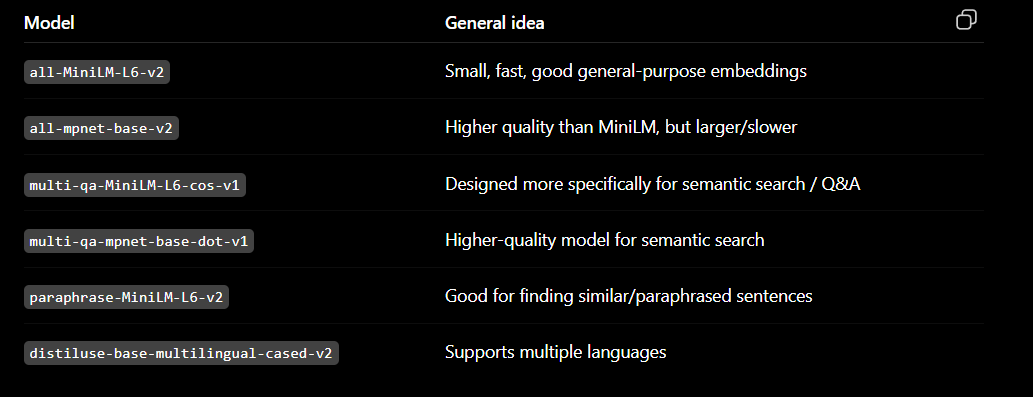

In [10]:
# Initialize the EmbeddingManager 
embedding_manager = EmbeddingManager()
embedding_manager

Loading embedding model: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3323.61it/s]


Model Loaded successfully. Embedding Dimension: 384


In [11]:
texts = [doc.page_content for doc in chunks]
embeddings = embedding_manager.generate_embeddings(texts)
embeddings

Generating embeddings for 39 texts...


Batches: 100%|██████████| 2/2 [00:01<00:00,  1.83it/s]

Generated embeddings with shape: (39, 384)


array([[-0.05657499,  0.04778868, -0.01558508, ..., -0.00263949,
        -0.05168089, -0.05544119],
       [-0.00950861, -0.01975231,  0.0149602 , ...,  0.01469684,
        -0.07350876, -0.07154063],
       [ 0.01186388,  0.01436791,  0.00539688, ...,  0.03117327,
        -0.04063996, -0.06489608],
       ...,
       [-0.02473076, -0.01798656,  0.03184623, ..., -0.0435037 ,
        -0.01492926,  0.08200853],
       [-0.05914009, -0.0124613 ,  0.01322934, ..., -0.0468333 ,
         0.02433613,  0.11327168],
       [-0.00322634, -0.02530112, -0.06791583, ..., -0.04213163,
        -0.04251898,  0.03750136]], shape=(39, 384), dtype=float32)

### VectorDB

In [12]:
class VectorStore:
  """Manages document embeddings in a ChromaDB vector store"""

  def __init__(self, collection_name: str= "pdf_documents", persist_directory: str = "../data/vector_store"):
    """
    Initialize the vector store

    Args: 
      collection_name: Name of the ChromaDB collection
      persist_directory: Directory to persist the vector store
    """

    self.collection_name = collection_name
    self.persist_directory = persist_directory
    self.client = None
    self.collection = None
    self._initialize_store()

  def _initialize_store(self):
    """Initialize ChromaDB client and collection"""
    try:
      # Create persistent ChormaDB client
      os.makedirs(self.persist_directory, exist_ok=True)
      self.client = chromadb.PersistentClient(path= self.persist_directory)

      # Get or create collection
      self.collection = self.client.get_or_create_collection(
        name = self.collection_name,
        metadata= {"description": "PDF document embeddings for RAG"}
      )
      print(f"vector store initialized. Collection: {self.collection_name}")
      print(f"Existing documents in collection: {self.collection.count()}")

    except Exception as e:
      print(f"Error initializing vector store: {e}")
      raise

  # Now add it to Vector DB 
  def add_documents(self, documents: List[Any], embeddings: np.ndarray):
    """
    Add documents and their embeddings to the vector store

    Args: 
      documents: List of LangChain documents
      embeddings: Corresponding embeddings for the documents 
    """
    if len(documents) != len(embeddings):
      raise ValueError("Number of documents must match number of embeddings")

    print(f"Adding {len(documents)} documents to vector store...")

    # Prepare data for ChromaDB
    ids = []
    metadatas = []
    documents_text = []
    embeddings_list = []

    for i, (doc, embedding) in enumerate(zip(documents, embeddings)):
      # Generate unique ID
      doc_id = f"doc_{uuid.uuid4().hex[:8]}_{i}"
      ids.append(doc_id)

      # Prepare metadata
      metadata = dict(doc.metadata)
      metadata['doc_index'] = i
      metadata['content_length'] = len(doc.page_content)
      metadatas.append(metadata)

      # Document content
      documents_text.append(doc.page_content)

      # Embedding
      embeddings_list.append(embedding.tolist())


    # Add to collection
    try:
      self.collection.add(
        ids= ids,
        embeddings=embeddings_list,
        metadatas= metadatas,
        documents= documents_text
      )
      print(f"Successfully added {len(documents)} documents to vector store")
      print(f"Total documents in collection: {self.collection.count()}")
    except Exception as e:
      print(f"Error adding documents to vector store: {e}")
      raise
    

In [13]:
print("Embeddings type:", type(embeddings))
print("Embeddings shape:", embeddings.shape)
print("First embedding shape:", embeddings[0].shape)

Embeddings type: <class 'numpy.ndarray'>
Embeddings shape: (39, 384)
First embedding shape: (384,)


In [14]:
vector_store = VectorStore()
vector_store.add_documents(chunks, embeddings)

vector store initialized. Collection: pdf_documents
Existing documents in collection: 39


## Retriever Pipeline From VectorStore

In [15]:
class RAGRetriever:
  """Handles query-based retrieval from the vector store"""

  def __init__(self, vector_store: VectorStore, embedding_manager: EmbeddingManager):
    """
    Initialize the RAGRetriever

    Args:
      vector_store: Vector store containing document embeddings
      embedding_manager: Manager for generating embeddings for queries
    """
    self.vector_store = vector_store
    self.embedding_manager = embedding_manager

  def retrieve(self, query: str, top_k: int = 5, score_threshold: float = 0.0) -> List[Dict[str, Any]]:
    """
    Retrieve relevent documents based on a query

    Args:
      query: The input query string
      top_k: Number of top documents to retrieve
      score_threshold: Minimum similarity score for retrieved documents

    Returns:
      A list of dictionaries, each containing a retrieved document and its similarity score.
    """
    print(f"Retrieveing documents for query: '{query}'")
    print(f"Top K: {top_k}, Score Threshold: {score_threshold}")

    # Generate embedding for the query
    query_embedding = self.embedding_manager.generate_embeddings([query])[0]

    
    try:
      
      # Search in the vector store
      results = self.vector_store.collection.query(
        query_embeddings= [query_embedding.tolist()],
        n_results= top_k,
      )

      # Process results
      retrieved_docs = []

      if results['documents'] and results['documents'][0]:
        documents = results['documents'][0]
        metadatas = results['metadatas'][0]
        distances = results['distances'][0]
        ids = results['ids'][0]

        for i, (doc_id, document, metadata, distance) in enumerate(zip(ids, documents, metadatas, distances)):
          similarity_score = 1 - distance  # Convert distance to similarity
          if similarity_score >= score_threshold:
            retrieved_docs.append({
              'id': doc_id,
              'document': document,
              'metadata': metadata,
              'similarity_score': similarity_score,
              'distance': distance,
              'rank': i + 1
            })

        print(f"Retrieved {len(retrieved_docs)} documents (after filtering)")
      else:
        print("No documents found.")

      return retrieved_docs
    except Exception as e:
      print(f"Error during retrieval: {e}")
      return []

          

In [16]:
rag_retriever = RAGRetriever(vector_store, embedding_manager)
rag_retriever.retrieve("tell me about Automatic Radiographic Bone Age Assessment Using Deep Joint Learning with Attention Modules")

Retrieveing documents for query: 'tell me about Automatic Radiographic Bone Age Assessment Using Deep Joint Learning with Attention Modules'
Top K: 5, Score Threshold: 0.0
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00,  6.15it/s]

Generated embeddings with shape: (1, 384)
Retrieved 5 documents (after filtering)


[{'id': 'doc_a8e675da_0',
  'document': 'Automatic Radiographic Bone Age \nAssessment Using Deep Joint Learning \nwith Attention Modules \nWei TANGa, Gang WU b and Gang SHENa,1 \na\n School of Software Engineering, Huazhong University of Science and Technology, \nWuhan, China \nb\n Tongji Hospital, Wuhan, China \n \nAbstract.\x03Hand and wrist skeletal radiographs serve as an important medium for \ndiversified medical and forensic tasks involving bone age assessment. As an \nalternative to traditional atlas-based bone age identification techniques, deep \nlearning algorithms automatically classify the radiographs into predefined bone \nage classes, provided that the deep neural networks (DNN) have been well \ntrained with large scale annotated datasets. Most of the current bone age \nclassification DNNs directly explore the existing network models developed for \nother computer vision representations and understanding applications, such as \nVGG, Inception, and ResNet. In this work, we

In [17]:
rag_retriever = RAGRetriever(vector_store, embedding_manager)
rag_retriever.retrieve("tell me about Inception Residual Modules") 

Retrieveing documents for query: 'tell me about Inception Residual Modules'
Top K: 5, Score Threshold: 0.0
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 90.94it/s]

Generated embeddings with shape: (1, 384)
Retrieved 1 documents (after filtering)


[{'id': 'doc_c1ca20cd_14',
  'document': 'Figure 4. Internal structure of module IncRes1. \n2.2. Inception Residual Modules \nLocal features in different scales may provide more and broader views to examine the \nrelations between X-ray images and the bone ages.  \nThere are two Inception Residual (IncRes) modules in TJ-Net, with slightly variant \nstructures. Block IncRes1 consists of several branches with diverse convolutional \nkernel sizes (see Fig. 4). The multi-scale branches combine \n, and \n \nconvolution kernels in particular ways. Additionally, IncRes2 has four inception \nbranches, namely \n, \n, \n, and \n respectively. Similarly, each of the \nmodules Inception1 and Inception2 has four multi-scale branches, the combinations of \n, \n, \n, \n, \n, \n, and \n. The convolutional outputs are \nconcatenated in the later stage. \n2.3. Loss Function for Joint Learning \nThe proposed loss function integrates the global classification errors over the training',
  'metadata': {'sou

## Integration Vectordb Context pipeline With LLM output

In [ ]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")
